In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
image = cv2.imread('sar_2_color.jpg')

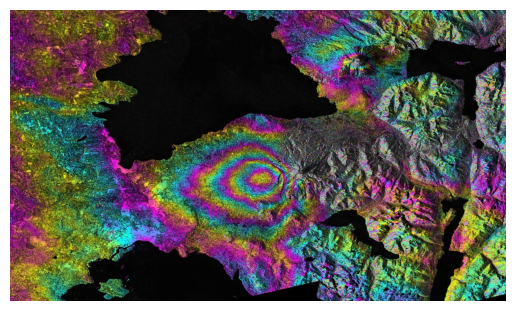

In [ ]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

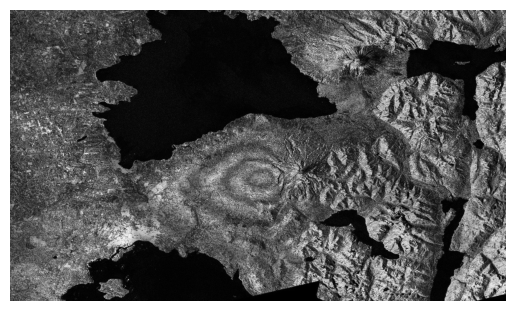

In [ ]:
#сера фото
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

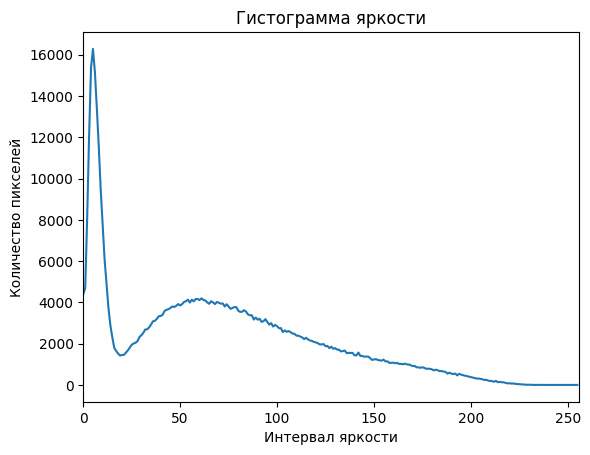

In [ ]:
#вывод гисты
hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

plt.plot(hist)
plt.title('Гистограмма яркости')
plt.xlabel('Интервал яркости')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.show()

In [ ]:
#написание функции считаем
def my_histogram(img):
    counts = [0] * 256
    for row in img:
        for pixel in row:
            counts[pixel] += 1
    return counts

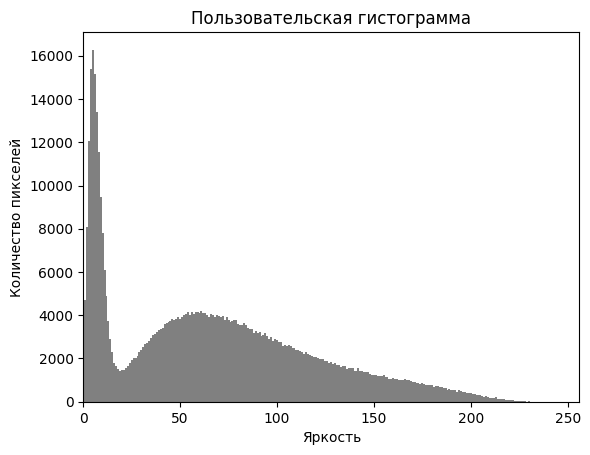

In [ ]:
#отрисовка гисты
custom_hist = my_histogram(gray_image)

plt.bar(range(256), custom_hist, width=1.0, color='gray')
plt.title('Пользовательская гистограмма')
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.show()

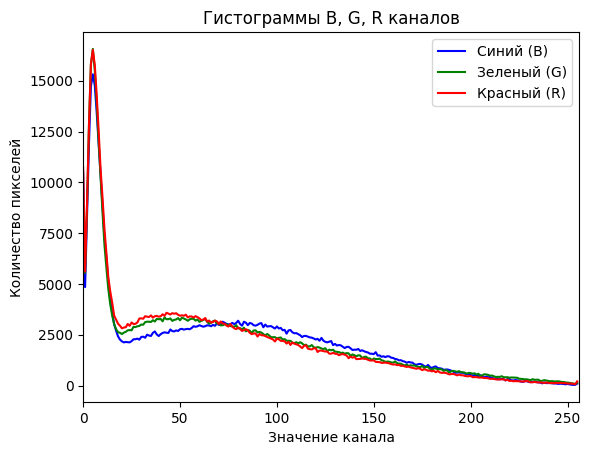

In [ ]:
# 0-blue, 1-green, 2-red
colors = ('b', 'g', 'r')
labels = ('Синий (B)', 'Зеленый (G)', 'Красный (R)')

plt.figure()
for i, (col, label) in enumerate(zip(colors, labels)):
    hist_channel = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist_channel, color=col, label=label)

plt.title('Гистограммы B, G, R каналов')
plt.xlabel('Значение канала')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.legend()
plt.show()

In [ ]:
#эквализация гисты
equalized_image = cv2.equalizeHist(gray_image)

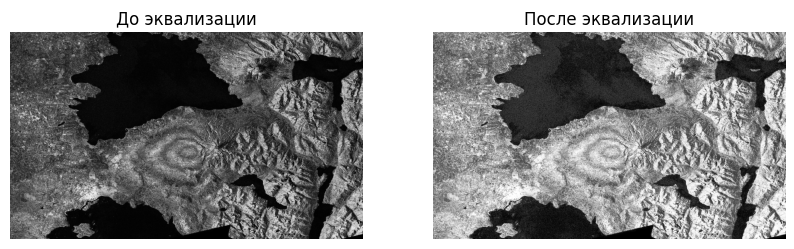

In [ ]:
#сравнение изображений до и после
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('До эквализации')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('После эквализации')
plt.axis('off')

plt.show()

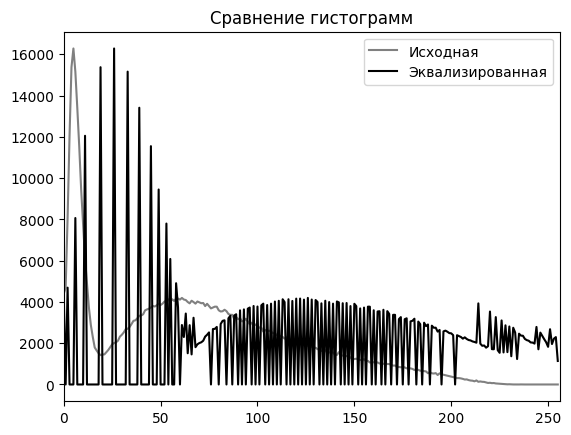

In [ ]:
#сравнение гистограмм до и после
hist_orig = cv2.calcHist([gray_image], [0], None, [256], [0, 256])
hist_eq = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])

plt.plot(hist_orig, color='gray', label='Исходная')
plt.plot(hist_eq, color='black', label='Эквализированная')
plt.title('Сравнение гистограмм')
plt.legend()
plt.xlim([0, 256])
plt.show()

In [ ]:
def statistical_color_correction(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)

    #L-яркость, a-зелено-красный, b-сине-желтый)
    l, a, b = cv2.split(lab)

    l_mean, l_std = l.mean(), l.std()

    target_mean = 128.0
    target_std = 50.0

    l_corrected = (l - l_mean) * (target_std / l_std) + target_mean

    l_corrected = np.clip(l_corrected, 0, 255)

    lab_corrected = cv2.merge([l_corrected, a, b]).astype(np.uint8)

    result_bgr = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    return result_bgr

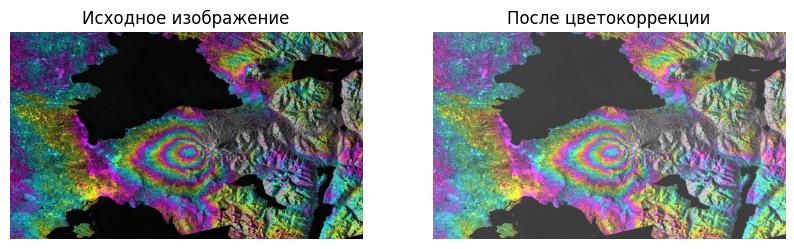

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(corrected_image, cv2.COLOR_BGR2RGB))
plt.title('После цветокоррекции')
plt.axis('off')

plt.show()

In [ ]:
#глобальная бинаризация оцу
_, otsu_bin = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#адаптивная бинаризация
adaptive_bin = cv2.adaptiveThreshold(
    gray_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

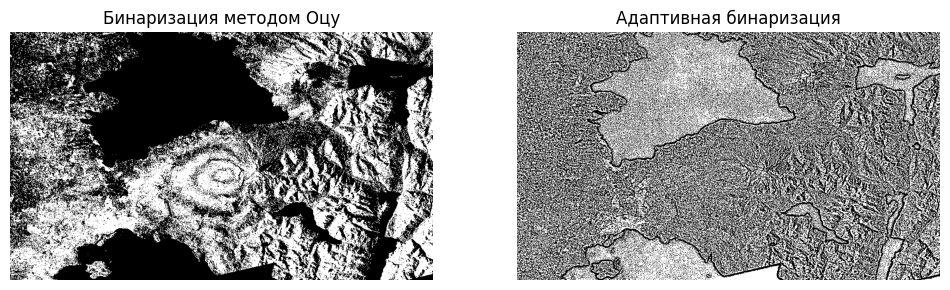

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(otsu_bin, cmap='gray')
plt.title('Бинаризация методом Оцу')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adaptive_bin, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')

plt.show()

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат
